In [1]:
import pandas as pd
import numpy as np
from plotnine import *
from anndata import read_h5ad


In [41]:
adata = read_h5ad('/Users/kylekimler/Projects/GCA/meta_datasets/healthy_concat_qc_CELLxGENE.h5ad')

meta = adata.obs



In [42]:
meta['cell_id'] = meta.index

In [72]:
df_dataset = pd.read_csv('/Users/kylekimler/gitHub/hca-gut-atlas-extension/src/harmonized_metadata/concatenated_dataset_metadata.csv').drop(columns=['index'])
df_sample = pd.read_csv('/Users/kylekimler/gitHub/hca-gut-atlas-extension/src/harmonized_metadata/concatenated_sample_metadata.csv').drop(columns=['index'])
df_donor = pd.read_csv('/Users/kylekimler/gitHub/hca-gut-atlas-extension/src/harmonized_metadata/concatenated_donor_metadata.csv').drop(columns=['index'])

# df_dataset.shape
df_sample.shape
# df_donor.shape

(770, 42)

In [43]:
# adata.obs.groupby('title')['sampled_site_condition'].value_counts()

In [44]:
summary_df = meta.groupby('title').agg(
    total_samples=('sample_id', 'nunique'),
    total_donors=('donor_id', 'nunique'),
    total_cells=('cell_id', 'size')  # Assuming 'cell_id' is the index or a column in the .obs attribute
).reset_index()


In [45]:
totals_df = summary_df
totals_df['title'] = 1

In [46]:
title_count = melted_df[melted_df['Category'] == 'title'].shape[0]  # Count all entries with 'title'
other_metrics = melted_df[melted_df['Category'] != 'title'].groupby('Category').sum().reset_index()

# Creating a new summary dataframe
summary_df = pd.DataFrame({
    'Category': ['title'] + other_metrics['Category'].tolist(),
    'Count': [title_count] + other_metrics['Count'].tolist()
})


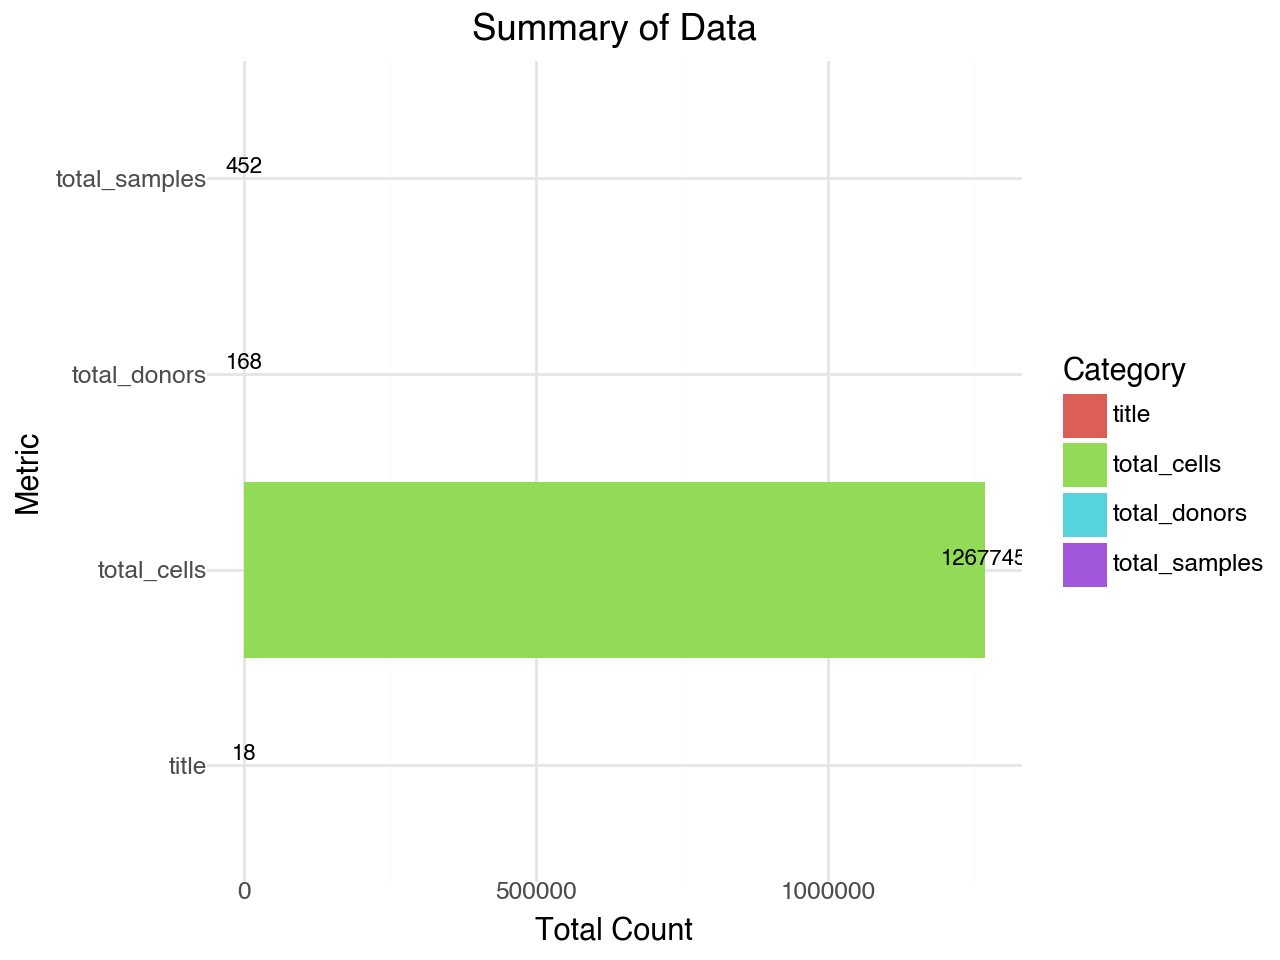

In [47]:
p = (ggplot(summary_df, aes(x='Category', y='Count', fill='Category'))
     + geom_bar(stat='identity', position='dodge')
     + geom_text(aes(label='Count'),
                 position=position_dodge(width=0.9),  # Adjust this width as necessary
                 va='bottom', size=8)
     + coord_flip()
     + theme_minimal()
     + labs(title='Summary of Data', y='Total Count', x='Metric')
)
p.show()  # Use show method to display the plot

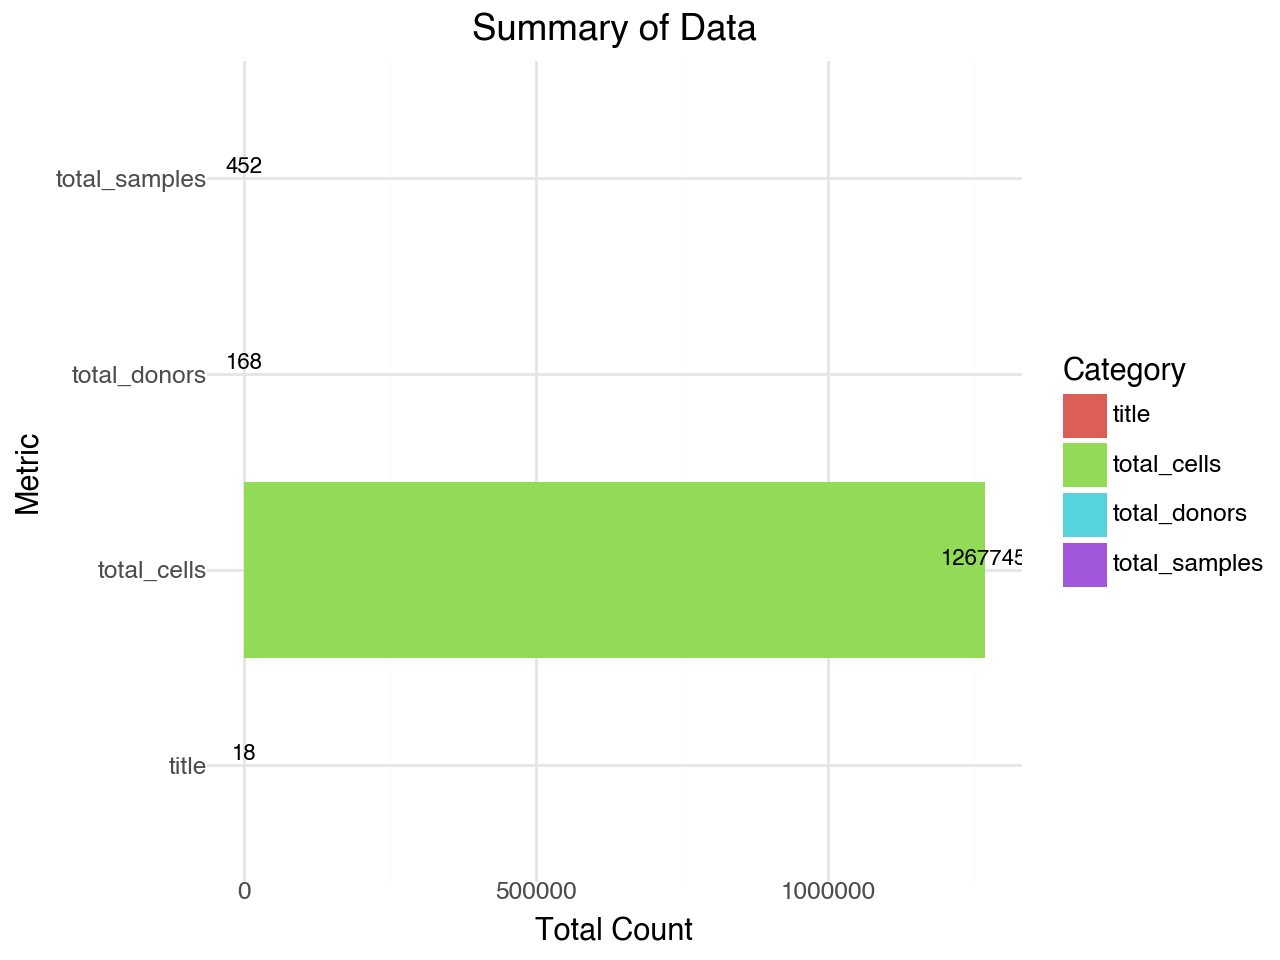

In [48]:
p = (ggplot(summary_df, aes(x='Category', y='Count', fill='Category'))
     + geom_bar(stat='identity', position='dodge')
     + geom_text(aes(label='Count'),
                 position=position_dodge(width=0.9),  # Adjust this width as necessary
                 va='bottom', size=8)
     + coord_flip()
     + theme_minimal()
     + labs(title='Summary of Data', y='Total Count', x='Metric')
)
p.show()  # Use show method to display the plot

In [49]:
adata

AnnData object with n_obs × n_vars = 1267745 × 16839
    obs: 'sample_id', 'donor_id', 'title', 'cell_ontology_term_id', 'author_cell_type', 'publication_doi', 'institute', 'contact_email', 'reference_genome', 'gene_annotation_version', 'alignment_software', 'intron_inclusion', 'ambient_count_correction', 'doublet_detection', 'study_pi', 'batch_condition', 'default_embedding', 'comments', 'protocol_url', 'consortia', 'description', 'doi', 'protocl_url', 'organism_ontology_term_id', 'manner_of_death', 'sex_ontology_term_id', 'disease_free_text', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term', 'organism', 'disease', 'self_reported_ethnicity_term_id', 'sample_collection_site', 'sample_collection_relative_time_point', 'library_id', 'library_id_repository', 'sample_source', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'tissue_ontology_term_id', 'tissue_ontology_term', 'radial_tissue_term', 'sample_preservation_method',

In [19]:
print(*meta['title'].unique())

stacking_values = ['Krzak2023', 'Boland2020']

agace_helmsley BasuHelmsley Maddipatla2023 Hickey2023 dominguez_2022 Kong2023 Luoma2020 Zheng2024 Egozi2023 KarakashevaHelmsley Elmentaite2021 He2020GenomeBio Huang2019 James2020 Kinchen2018 Parikh2019 Uzzan2022 Yu2021


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_59182/2518964651.py:80: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


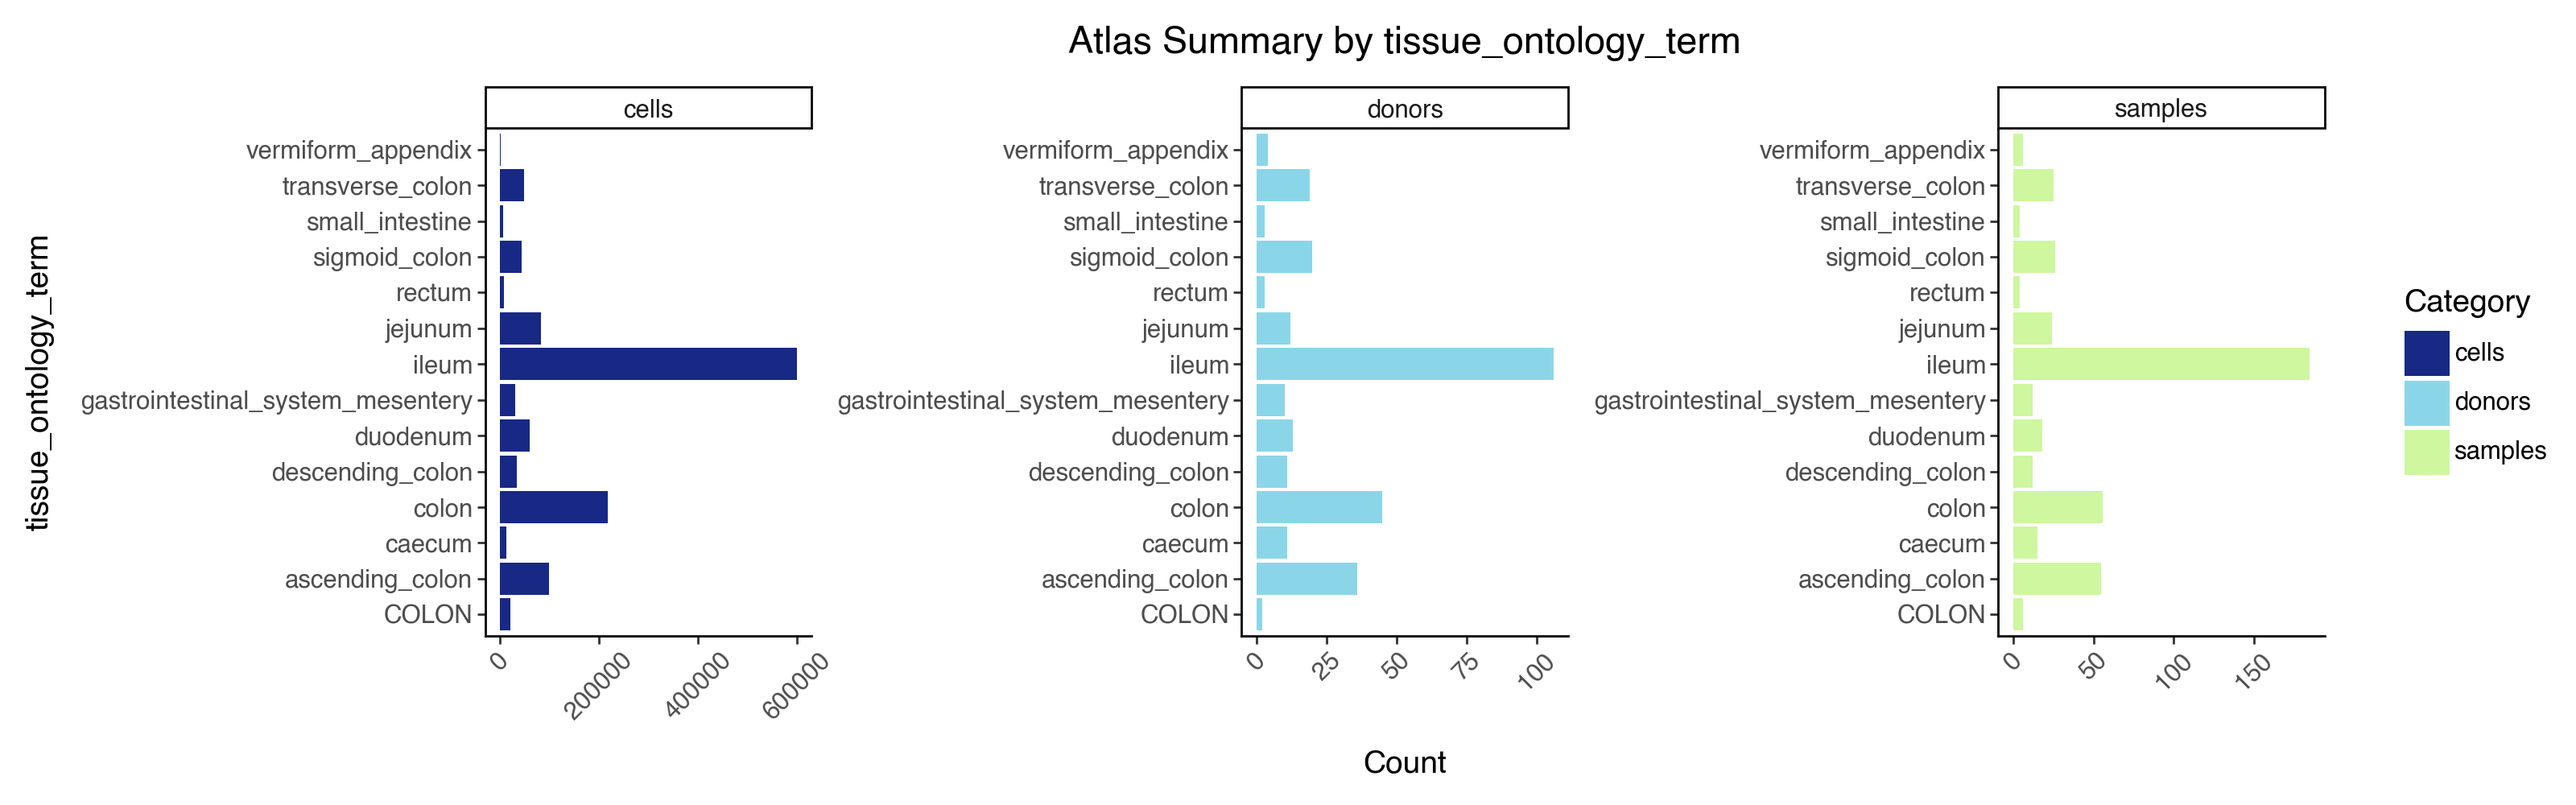

In [52]:
import pandas as pd
from plotnine import ggplot, aes, geom_bar, coord_flip, facet_wrap, theme_classic, element_text, theme, scale_fill_manual, labs, facet_grid

def create_faceted_bar_graph(df, grouping_var, color_palette, stacking_var=None, stacking_values=None):
    # Compute summary statistics per group
    if stacking_var:
        summary_df = df.groupby([grouping_var, stacking_var], observed=True).agg(
            samples=('sample_id', 'nunique'),
            donors=('donor_id', 'nunique'),
            cells=('cell_id', 'size')  # Assuming 'cell_id' is the index or a column in .obs
        ).reset_index()

        # Melt the DataFrame for easier plotting with facets
        melted_df = summary_df.melt(id_vars=[grouping_var, stacking_var],
                                    var_name='Category', value_name='Count')

        # Add a new column to identify records that fall within the stacking_values or outside it
        melted_df['Group'] = melted_df[stacking_var].apply(lambda x: 'Not in integration' if x in stacking_values else 'In integration')

        # Plot with stacking
        p = (
            ggplot(melted_df, aes(x=grouping_var, y='Count', fill='Group'))
            + geom_bar(stat='identity', position='stack')
            + coord_flip()
            + facet_wrap('~Category', scales='free')
            + theme_classic(base_size=14)
            + theme(
                axis_text_x=element_text(rotation=45, hjust=0.5), 
                axis_text_y=element_text(hjust=1),  # Justify y-axis labels
                legend_position='right', 
                subplots_adjust={'right': 0.85},
                figure_size=(16, 8))  # Adjust figure size for long labels
            + scale_fill_manual(values=color_palette + ['#dddddd'])  # Colors for 'Not in integration'
            + labs(title='Atlas Summary by ' + grouping_var, x=grouping_var, y='Count')
        )

    else:
        summary_df = df.groupby(grouping_var, observed=True).agg(
            samples=('sample_id', 'nunique'),
            donors=('donor_id', 'nunique'),
            cells=('cell_id', 'size')
        ).reset_index()

        # Melt the DataFrame for easier plotting with facets
        melted_df = summary_df.melt(id_vars=[grouping_var],
                                    var_name='Category', value_name='Count')

        # Plot without stacking
        p = (
            ggplot(melted_df, aes(x=grouping_var, y='Count', fill='Category'))
            + geom_bar(stat='identity', position='dodge')
            + coord_flip()
            + facet_wrap('~Category', scales='free')
            + theme_classic(base_size=14)
            + theme(
                axis_text_x=element_text(rotation=45, hjust=0.5), 
                axis_text_y=element_text(hjust=1),  # Justify y-axis labels
                legend_position='right', 
                subplots_adjust={'right': 0.85},
                figure_size=(16, 8))  # Adjust figure size for long labels
            + scale_fill_manual(values=color_palette)
            + labs(title='Atlas Summary by ' + grouping_var, x=grouping_var, y='Count')
        )

    # Remove y-axis tick labels for the second and third facets
    p = p + theme(
        strip_text_y=element_blank()
    )

    return p



/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_59182/1758188934.py:15: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


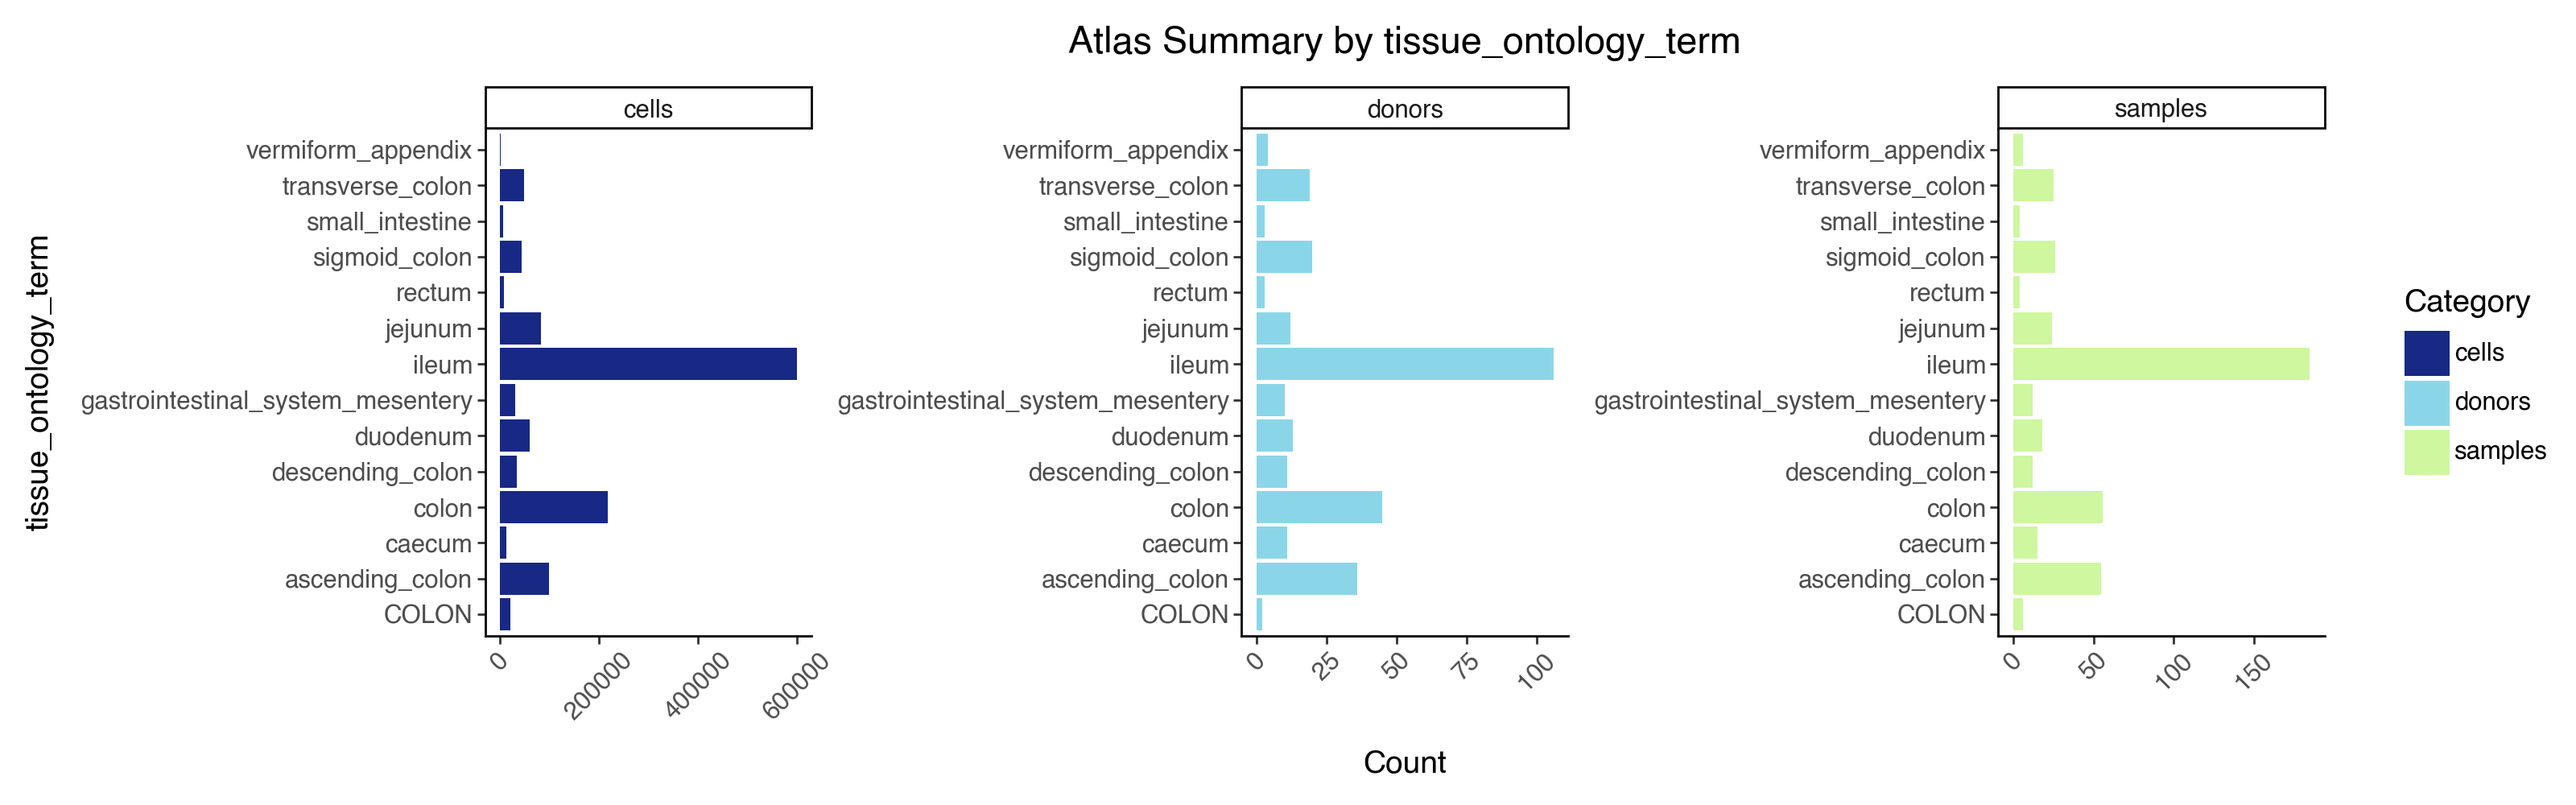

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/June2024_meeting/plots/tissue_ontology_term_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [54]:
group = 'tissue_ontology_term'

file_path = f"/Users/kylekimler/Projects/GCA/June2024_meeting/plots/{group}_summary.png"

# Example usage
plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = ['#172984','#8AD6E8', '#CEF7A0'], 
                                # stacking_var='title', 
                                # stacking_values=['Krzak2023', 'Boland2020']
                               )

wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))
plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_59182/1465301620.py:15: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


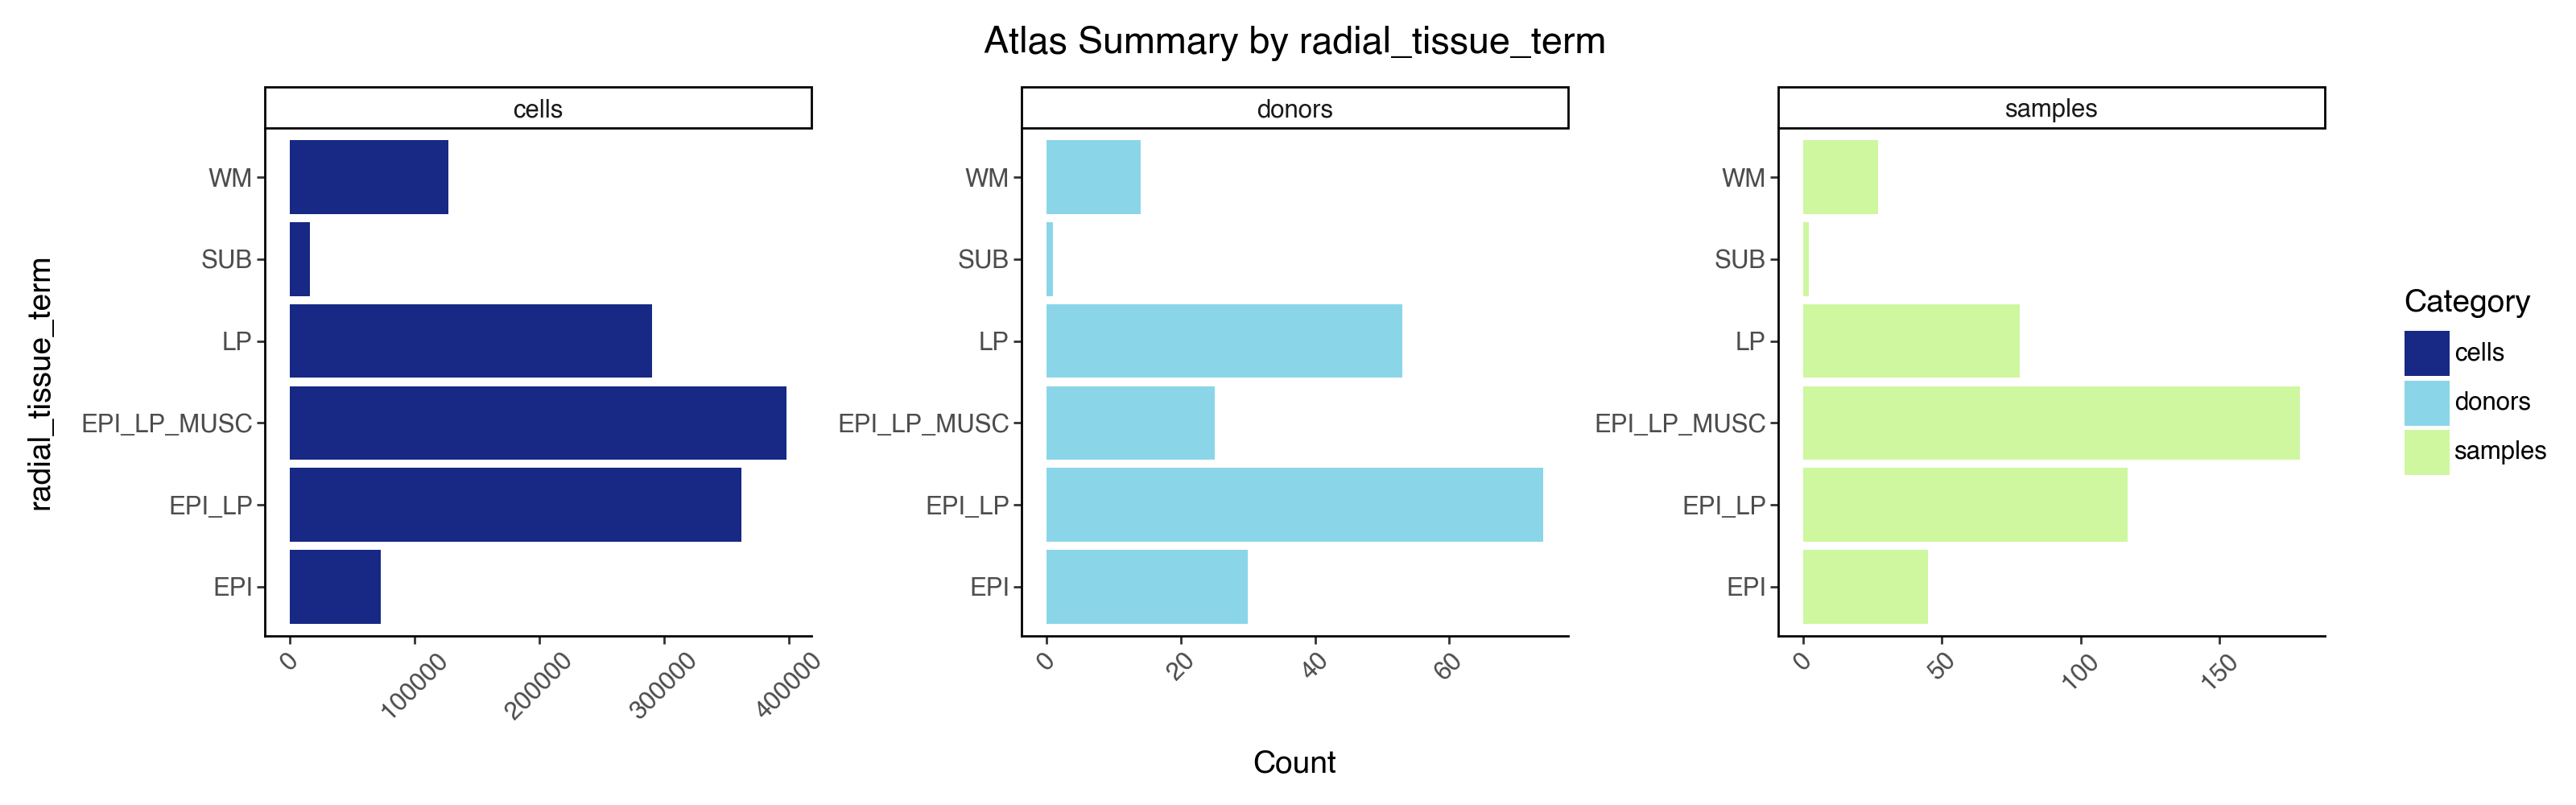

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/June2024_meeting/plots/radial_tissue_term_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [55]:
group = 'radial_tissue_term'

file_path = f"/Users/kylekimler/Projects/GCA/June2024_meeting/plots/{group}_summary.png"

# Example usage
plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = ['#172984','#8AD6E8', '#CEF7A0'], 
                                # stacking_var='title', 
                                # stacking_values=['Krzak2023', 'Boland2020']
                               )

wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))
plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_59182/1040121953.py:15: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


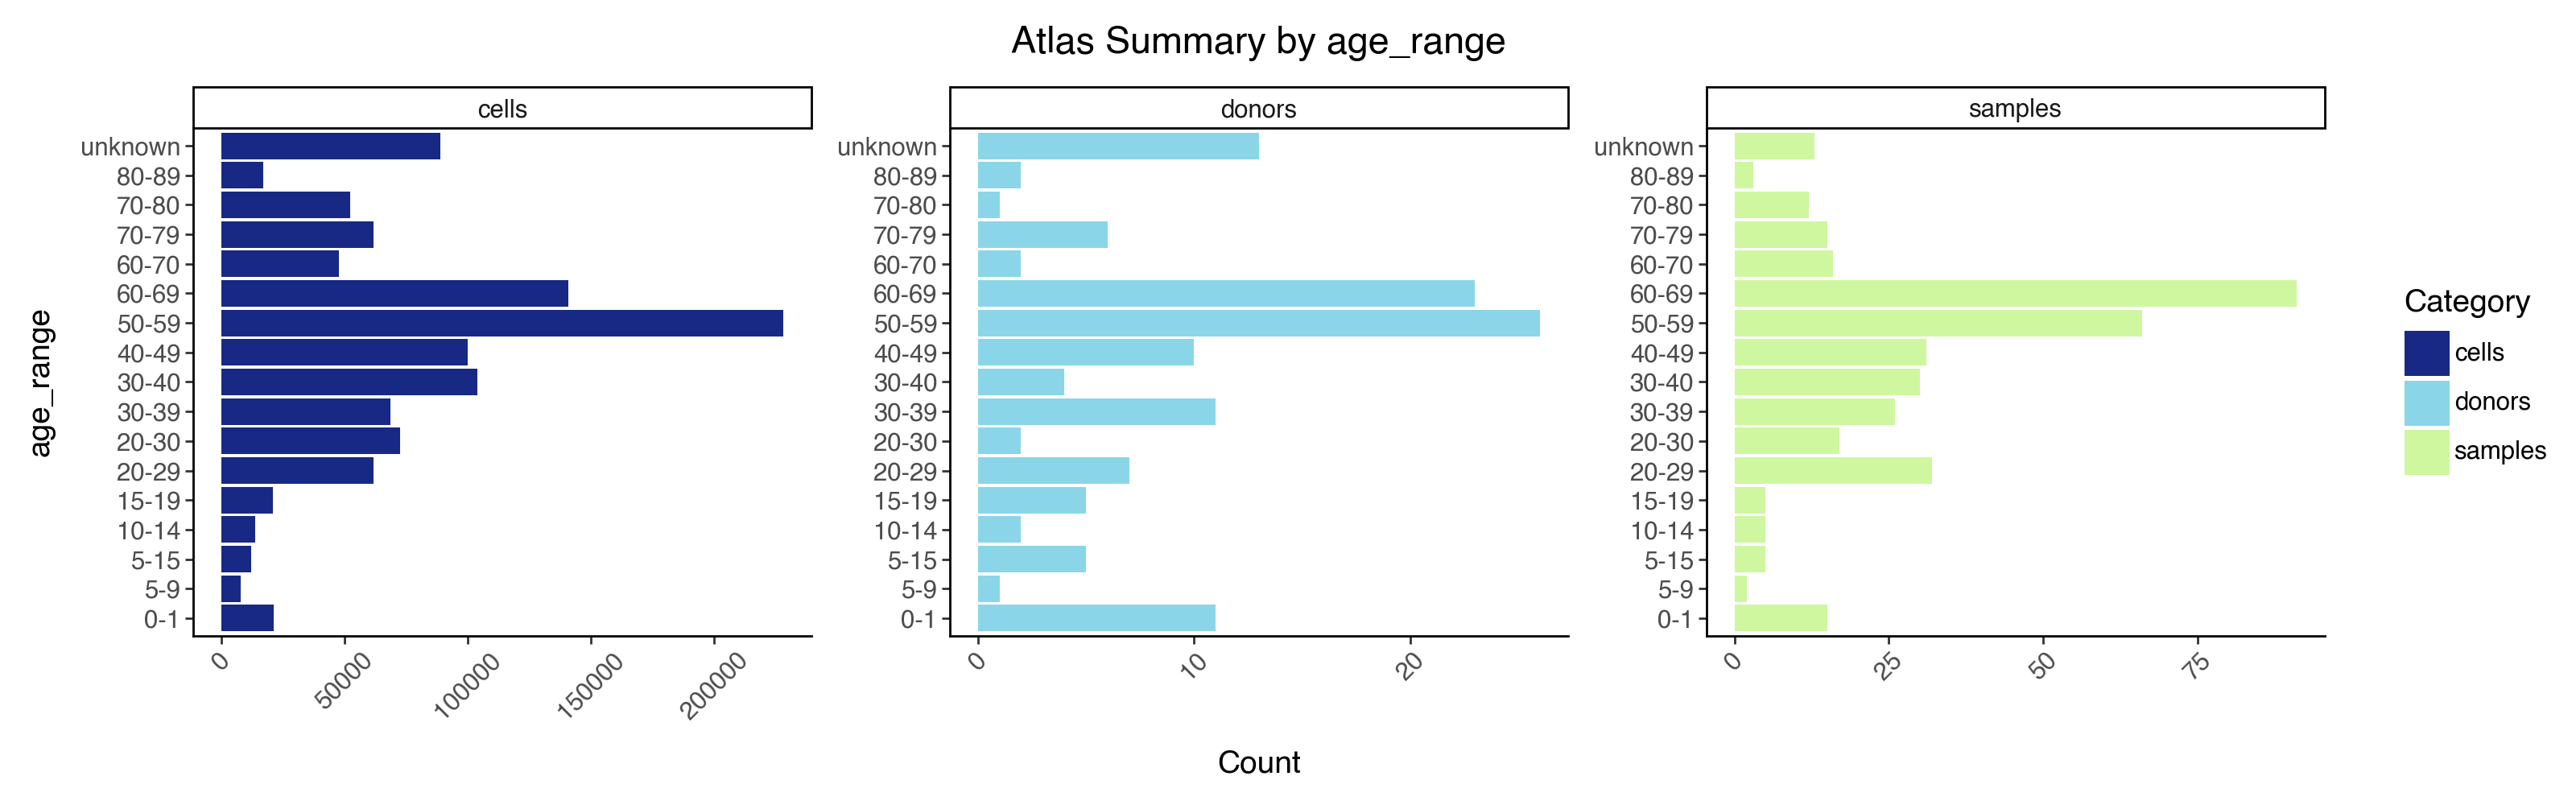

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/June2024_meeting/plots/age_range_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [56]:
group = 'age_range'

file_path = f"/Users/kylekimler/Projects/GCA/June2024_meeting/plots/{group}_summary.png"

# Example usage
plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = ['#172984','#8AD6E8', '#CEF7A0'], 
                                # stacking_var='title', 
                                # stacking_values=['Krzak2023', 'Boland2020']
                               )

wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))
plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_59182/590554184.py:15: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


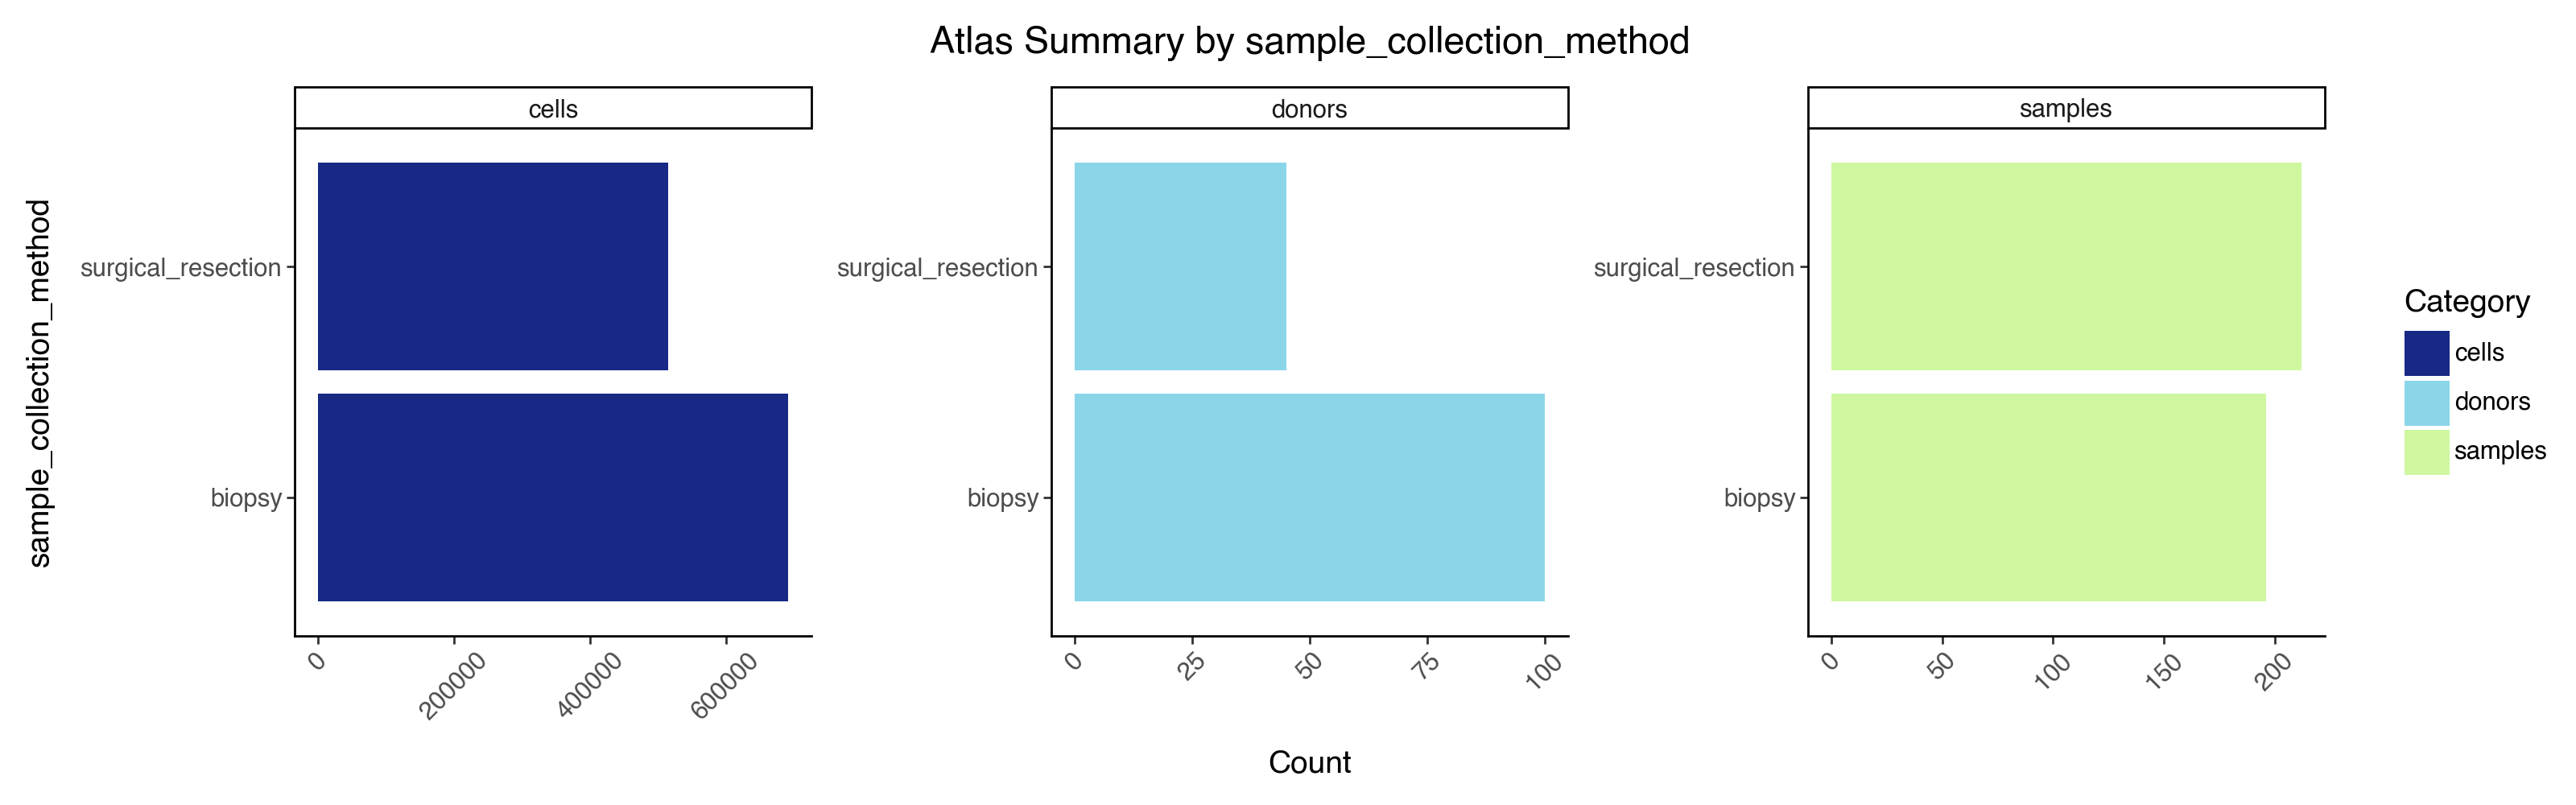

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/June2024_meeting/plots/sample_collection_method_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [60]:
group = 'sample_collection_method'

file_path = f"/Users/kylekimler/Projects/GCA/June2024_meeting/plots/{group}_summary.png"

# Example usage
plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = ['#172984','#8AD6E8', '#CEF7A0'], 
                                # stacking_var='title', 
                                # stacking_values=['Krzak2023', 'Boland2020']
                               )

wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))
plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_59182/2626253658.py:15: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


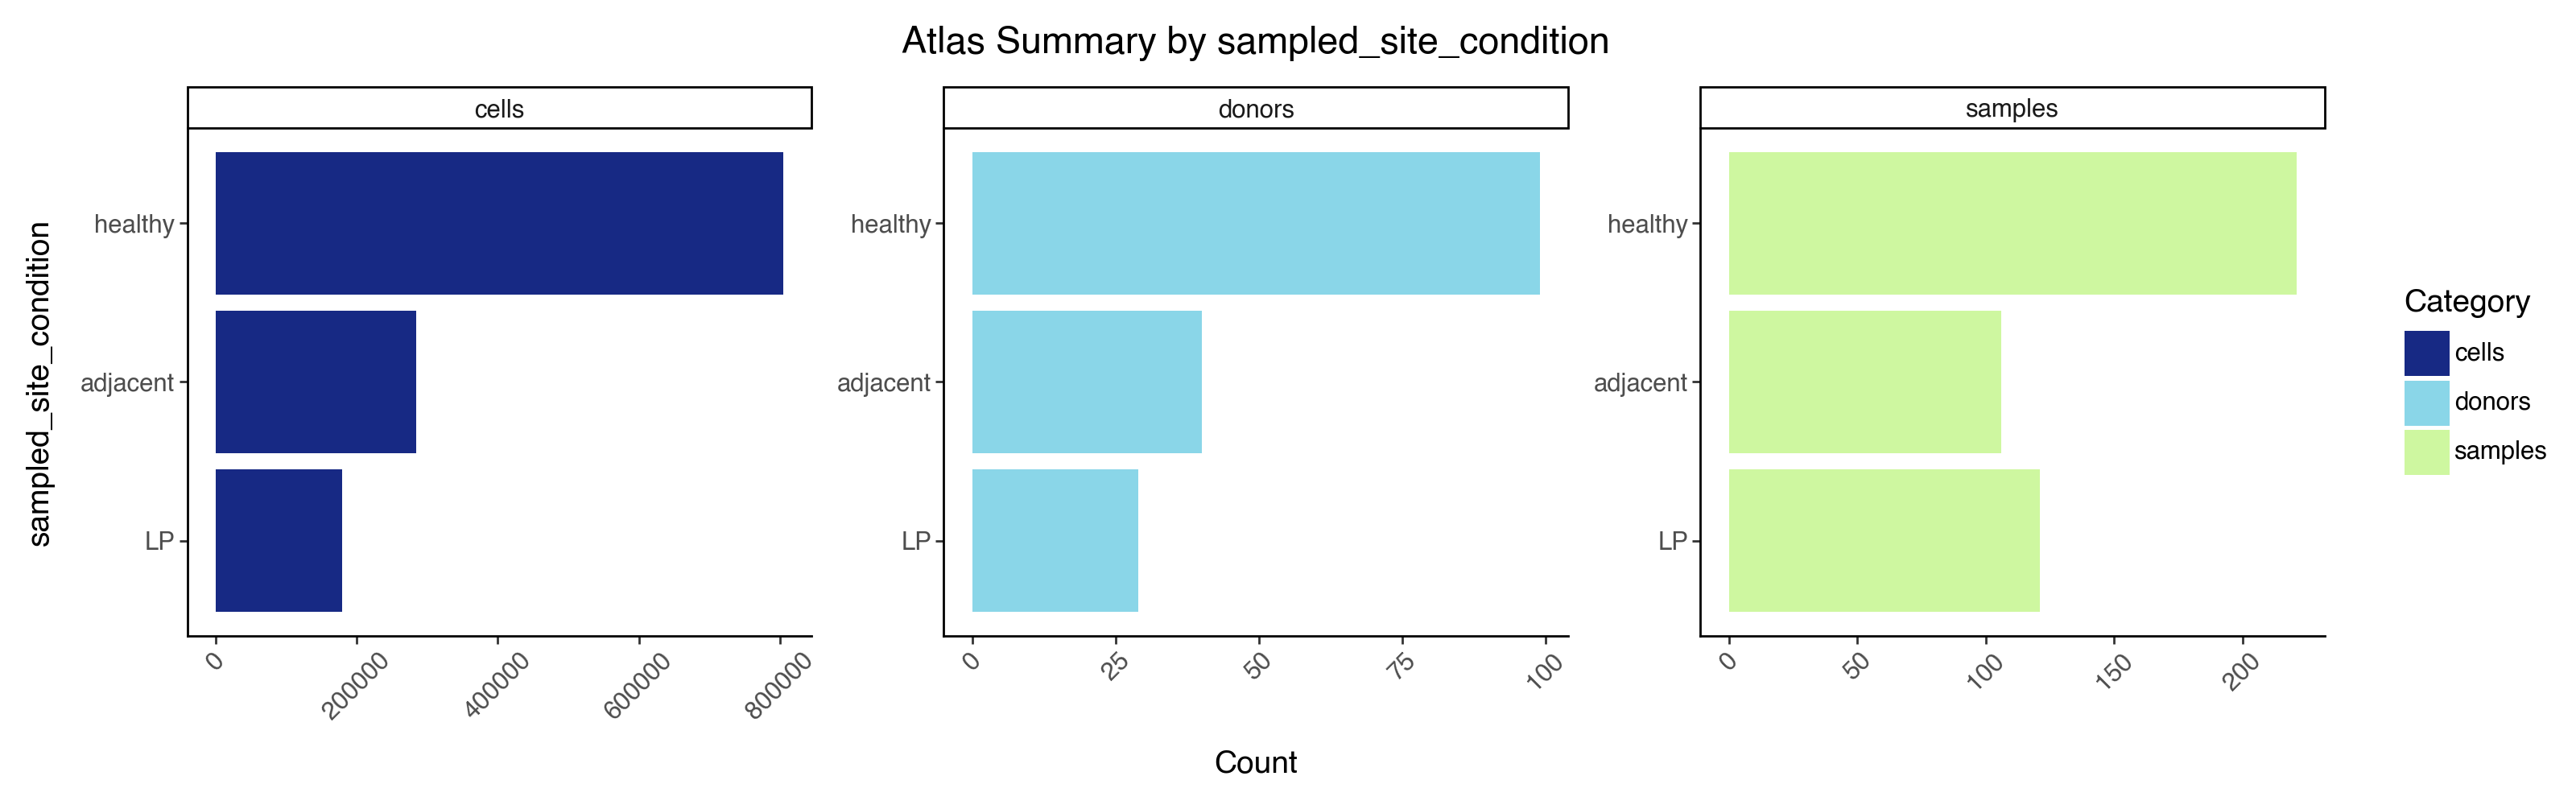

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/June2024_meeting/plots/sampled_site_condition_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [61]:
group = 'sampled_site_condition'

file_path = f"/Users/kylekimler/Projects/GCA/June2024_meeting/plots/{group}_summary.png"

# Example usage
plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = ['#172984','#8AD6E8', '#CEF7A0'], 
                                # stacking_var='title', 
                                # stacking_values=['Krzak2023', 'Boland2020']
                               )

wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))
plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_59182/456614917.py:15: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


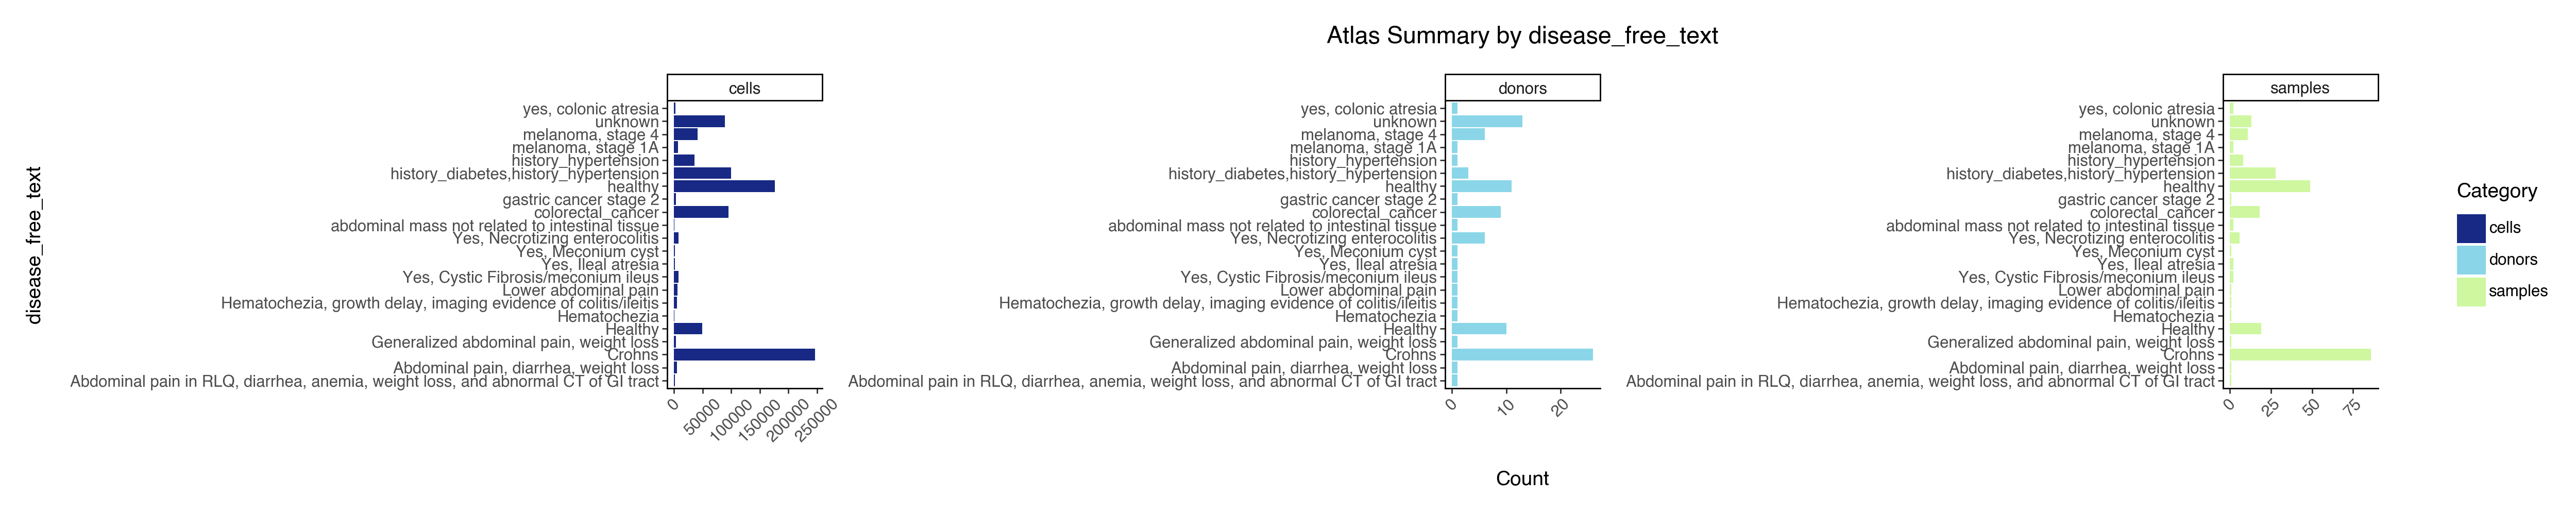

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 25 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/June2024_meeting/plots/disease_free_text_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [64]:
group = 'disease_free_text'

file_path = f"/Users/kylekimler/Projects/GCA/June2024_meeting/plots/{group}_summary.png"

# Example usage
plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = ['#172984','#8AD6E8', '#CEF7A0'], 
                                # stacking_var='title', 
                                # stacking_values=['Krzak2023', 'Boland2020']
                               )

wid = 25
hi = 5
print(plot + theme(figure_size=(wid, hi)))
plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_59182/518992076.py:15: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


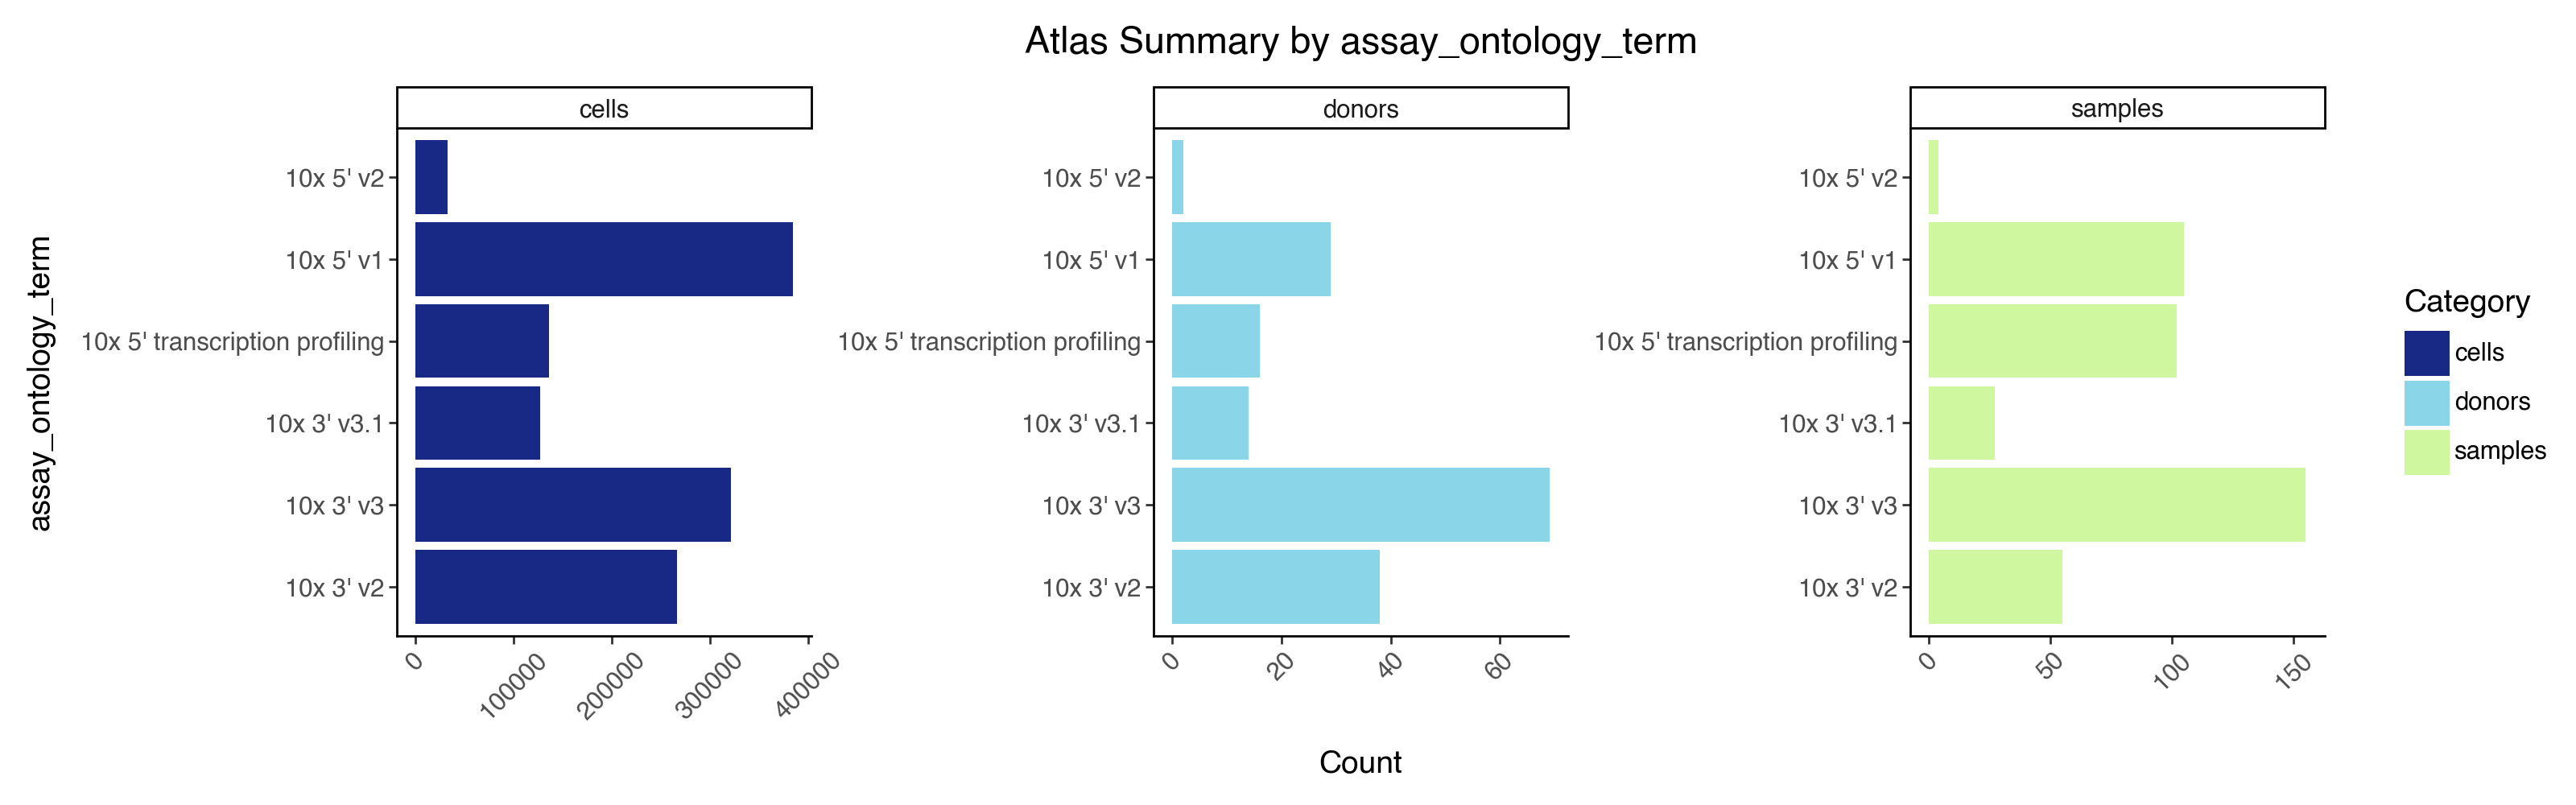

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/June2024_meeting/plots/assay_ontology_term_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [65]:
group = 'assay_ontology_term'

file_path = f"/Users/kylekimler/Projects/GCA/June2024_meeting/plots/{group}_summary.png"

# Example usage
plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = ['#172984','#8AD6E8', '#CEF7A0'], 
                                # stacking_var='title', 
                                # stacking_values=['Krzak2023', 'Boland2020']
                               )

wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))
plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


/var/folders/zc/5fly3ly908xb0pd8zy6m6bj80000gn/T/ipykernel_59182/3684897541.py:15: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


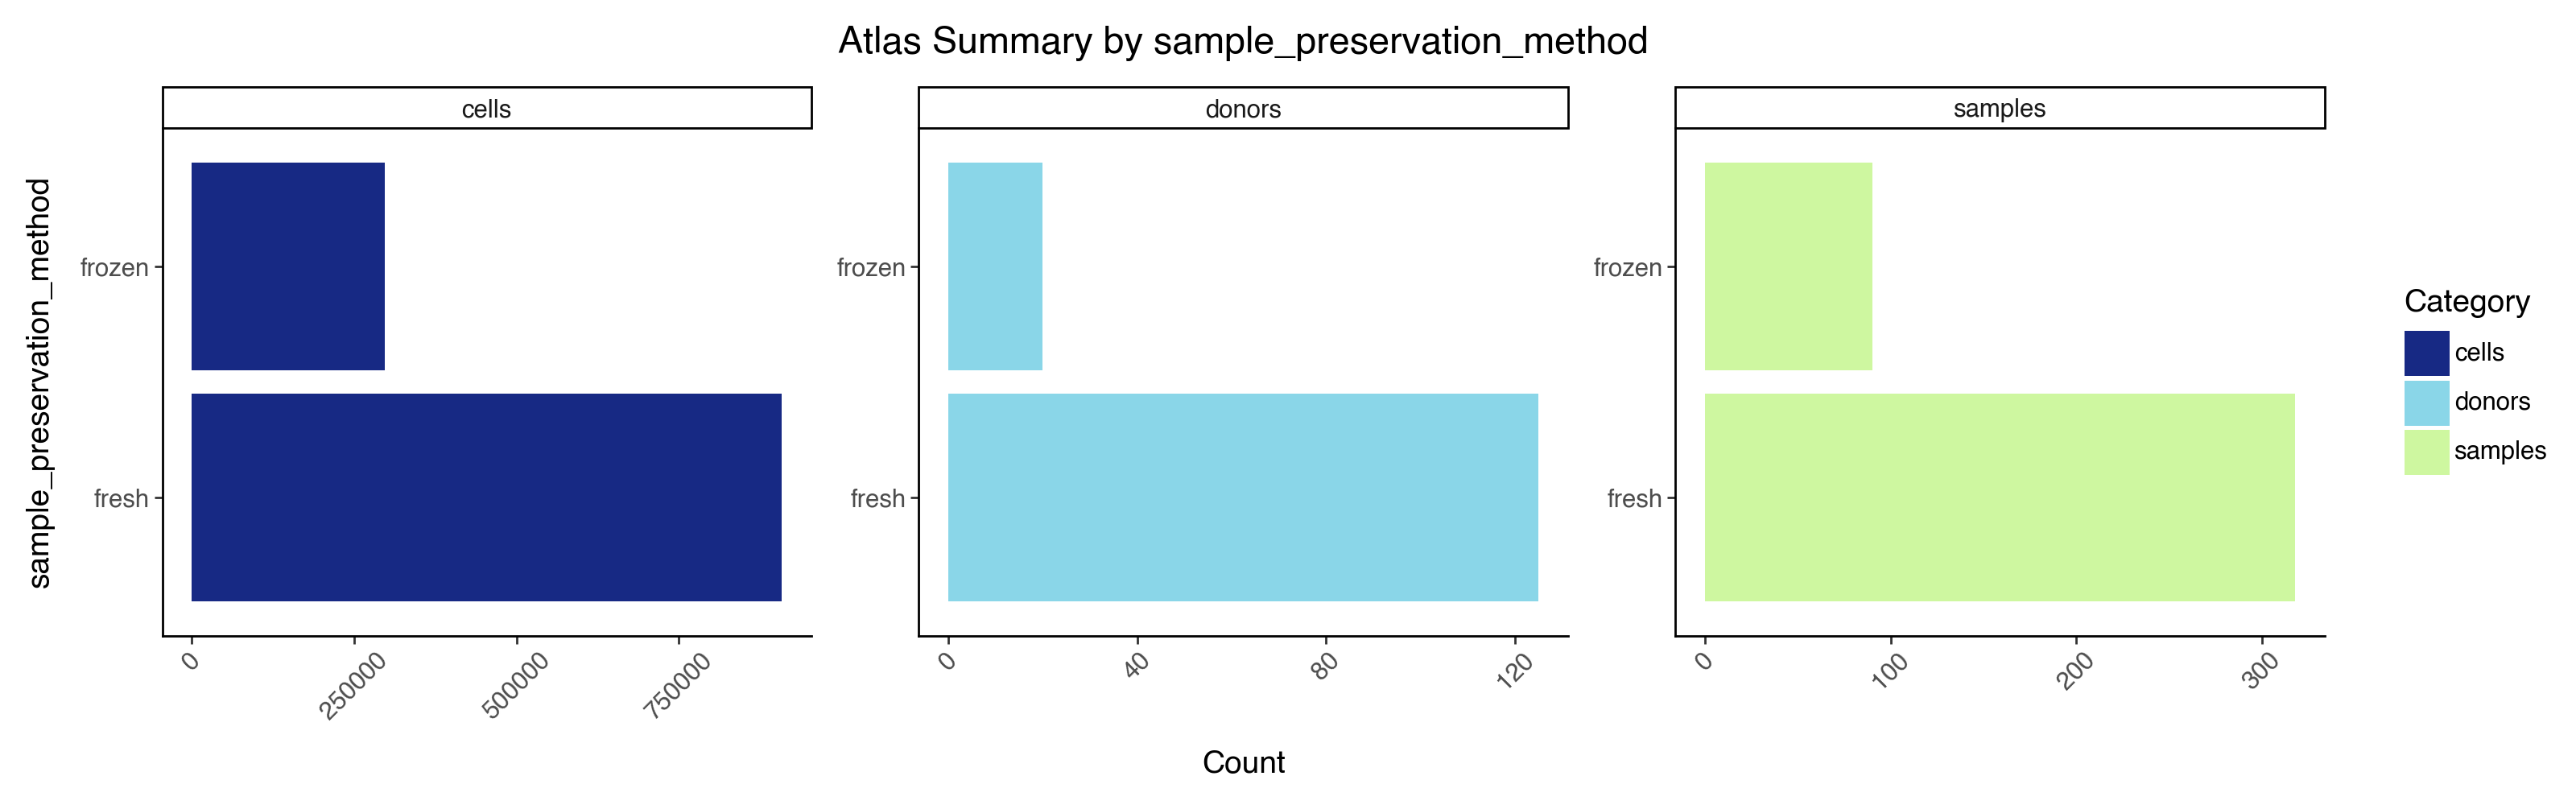

/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:606: PlotnineWarning: Saving 16 x 5 in image.
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/ggplot.py:607: PlotnineWarning: Filename: /Users/kylekimler/Projects/GCA/June2024_meeting/plots/sample_preservation_method_summary.png
/Users/kylekimler/.pyenv/versions/3.11.8/lib/python3.11/site-packages/plotnine/themes/themeable.py:2419: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


In [66]:
group = 'sample_preservation_method'

file_path = f"/Users/kylekimler/Projects/GCA/June2024_meeting/plots/{group}_summary.png"

# Example usage
plot = create_faceted_bar_graph(meta, 
                                grouping_var=group, 
                                color_palette = ['#172984','#8AD6E8', '#CEF7A0'], 
                                # stacking_var='title', 
                                # stacking_values=['Krzak2023', 'Boland2020']
                               )

wid = 16
hi = 5
print(plot + theme(figure_size=(wid, hi)))
plot.save(filename=file_path, width=wid, height=hi, units='in', dpi=300)


AnnData object with n_obs × n_vars = 1510893 × 59254
    obs: 'title', 'donor_id_x', 'sample_id', 'publication_doi', 'institute', 'contact_email', 'reference_genome', 'gene_annotation_version', 'alignment_software', 'intron_inclusion', 'ambient_count_correction', 'doublet_detection', 'study_pi', 'batch_condition', 'default_embedding', 'comments', 'protocol_url', 'consortia', 'description', 'worksheet_x', 'organism_ontology_term_id', 'manner_of_death', 'sex_ontology_term_id', 'disease_free_text', 'disease_ontology_term_id', 'disease_ontology_term', 'self_reported_ethnicity_ontology_term_id', 'worksheet_y', 'organism', 'disease', 'self_reported_ethnicity_term_id', 'sample_collection_relative_time_point', 'sample_source', 'sample_collection_method', 'tissue_type', 'sampled_site_condition', 'tissue_ontology_term_id', 'tissue_ontology_term', 'radial_tissue_term', 'sample_preservation_method', 'suspension_type', 'cell_enrichment', 'sample_collection_year', 'assay_ontology_term_id', 'sequence